In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
titanic = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'age', 'fare', 'embarked']
target = ['survived']

In [3]:
#handle missing values

imp_median = SimpleImputer(strategy="median")
titanic[[ "age" ]] = imp_median.fit_transform(titanic[[ "age" ]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[[ "embarked" ]] = imp_freq.fit_transform(titanic[[ "embarked" ]])

In [4]:
# encode 
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic[["sex"]])
titanic["embarked"] = le.fit_transform(titanic[[ "embarked" ]])

c:\Users\ayush\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ayush\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
X = titanic[features]
y = titanic[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
# Decision Tree 
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train)*100, "%")
print("Test Accuracy:", accuracy_score(y_test, y_pred_test)*100, "%")
#classic case of overfitting, where the model performs well on training data but poorly on test data.

Train Accuracy: 97.91332263242376 %
Test Accuracy: 76.49253731343283 %


[Text(0.3205149580792683, 0.9772727272727273, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.13592479674796748, 0.9318181818181818, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.22821987741361788, 0.9545454545454546, 'True  '),
 Text(0.03861788617886179, 0.8863636363636364, 'age <= 2.5\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.016260162601626018, 0.8409090909090909, 'fare <= 88.775\ngini = 0.5\nsamples = 2\nvalue = [1, 1]\nclass = Died'),
 Text(0.008130081300813009, 0.7954545454545454, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Survived'),
 Text(0.024390243902439025, 0.7954545454545454, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Died'),
 Text(0.06097560975609756, 0.8409090909090909, 'fare <= 149.035\ngini = 0.054\nsamples = 108\nvalue = [3, 105]\nclass = Survived'),
 Text(0.04065040650406504, 0.7954545454545454, 'age <= 49.5\ngini = 0.041\nsamples = 96\nva

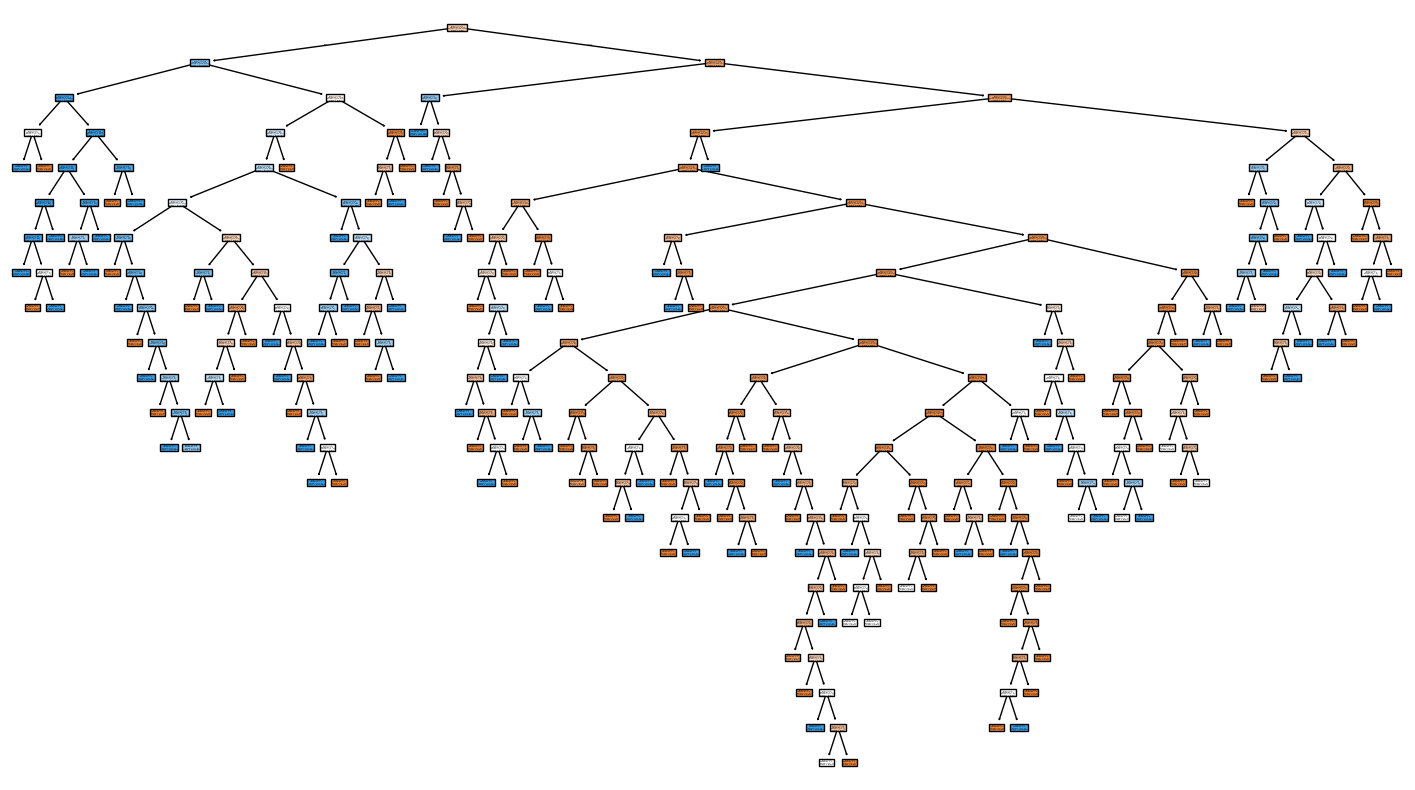

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"], 
    filled=True
)